# Instalaciones

In [92]:
# %pip install jenkspy
# %pip install scikit-posthocs
# %pip install jinja2



## Importaciones

In [93]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import spearmanr
import jenkspy
import scikit_posthocs as sp
from scipy.stats import kruskal
import scikit_posthocs as sp
from scipy.stats import mannwhitneyu
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor


## Carga del Dataset

In [94]:
df = pd.read_csv("../Data/data_cleaning_2026_04_05.csv")

In [95]:
df.columns

Index(['id', 'motivo_ausencia', 'mes_ausencia', 'dia_semana', 'estaciones',
       'gasto_transporte', 'distancia_casa_trabajo', 'tiempo_servicio', 'edad',
       'carga_trabajo_diaria', 'cumplimiento_objetivo', 'falta_disciplinaria',
       'educacion', 'hijos', 'bebedor_social', 'fumador_social', 'mascota',
       'peso', 'estatura', 'indice_masa_corporal', 'horas_ausentismo',
       'indicador_enfermedad', 'motivo_ausencia_mapeado',
       'mes_ausencia_mapeado', 'educacion_mapeada'],
      dtype='object')

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056 entries, 0 to 1055
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       1056 non-null   int64  
 1   motivo_ausencia          1056 non-null   int64  
 2   mes_ausencia             1051 non-null   float64
 3   dia_semana               1056 non-null   object 
 4   estaciones               1056 non-null   object 
 5   gasto_transporte         1056 non-null   int64  
 6   distancia_casa_trabajo   1056 non-null   int64  
 7   tiempo_servicio          1056 non-null   int64  
 8   edad                     1056 non-null   int64  
 9   carga_trabajo_diaria     1056 non-null   float64
 10  cumplimiento_objetivo    1056 non-null   int64  
 11  falta_disciplinaria      1056 non-null   int64  
 12  educacion                1056 non-null   int64  
 13  hijos                    1056 non-null   int64  
 14  bebedor_social          

## Transformación de datos

In [97]:
df_clean = df.loc[:, ~df.columns.isin(['mascota', 'peso', 'estatura'])]

In [98]:
df_clean[df_clean['horas_ausentismo'] == 0]

,id,motivo_ausencia,mes_ausencia,dia_semana,estaciones,gasto_transporte,distancia_casa_trabajo,tiempo_servicio,edad,carga_trabajo_diaria,...,educacion,hijos,bebedor_social,fumador_social,indice_masa_corporal,horas_ausentismo,indicador_enfermedad,motivo_ausencia_mapeado,mes_ausencia_mapeado,educacion_mapeada
662,36,0,7.0,Martes,Verano,118,13,18,50,239.554,...,1,1,1,0,31,0,NaN,NaN,Julio,Bachillerato
663,20,0,9.0,Lunes,Primavera,260,50,11,36,241.476,...,1,4,1,0,23,0,NaN,NaN,Septiembre,Bachillerato
664,29,0,9.0,Lunes,Primavera,225,26,9,28,241.476,...,1,1,0,0,24,0,NaN,NaN,Septiembre,Bachillerato
665,11,0,9.0,Martes,Primavera,289,36,13,33,241.476,...,1,2,1,0,30,0,NaN,NaN,Septiembre,Bachillerato
666,36,0,9.0,Martes,Primavera,118,13,18,50,241.476,...,1,1,1,0,31,0,NaN,NaN,Septiembre,Bachillerato
667,13,0,9.0,Miercoles,Primavera,369,17,12,31,241.476,...,1,3,1,0,25,0,NaN,NaN,Septiembre,Bachillerato
668,36,0,10.0,Miercoles,Primavera,118,13,18,50,253.465,...,1,1,1,0,31,0,NaN,NaN,Octubre,Bachillerato
669,34,27,1.0,Lunes,Otoño,118,10,10,37,308.593,...,1,0,0,0,28,0,No Enfermedad,Fisioterapia,Enero,Bachillerato
670,2,0,4.0,Lunes,Invierno,235,29,12,48,326.452,...,1,1,0,1,33,0,NaN,NaN,Abril,Bachillerato
671,7,0,5.0,Miercoles,Invierno,279,5,14,39,378.884,...,1,2,1,1,24,0,NaN,NaN,Mayo,Bachillerato


Miro cuantos registro sin horas y sin faltas hay

In [99]:
df_clean[(df_clean['horas_ausentismo'] == 0) & (df_clean['falta_disciplinaria'] == 0)]

,id,motivo_ausencia,mes_ausencia,dia_semana,estaciones,gasto_transporte,distancia_casa_trabajo,tiempo_servicio,edad,carga_trabajo_diaria,...,educacion,hijos,bebedor_social,fumador_social,indice_masa_corporal,horas_ausentismo,indicador_enfermedad,motivo_ausencia_mapeado,mes_ausencia_mapeado,educacion_mapeada
669,34,27,1.0,Lunes,Otoño,118,10,10,37,308.593,...,1,0,0,0,28,0,No Enfermedad,Fisioterapia,Enero,Bachillerato
703,4,0,NaN,Martes,Verano,118,14,13,40,271.219,...,1,1,1,0,34,0,NaN,NaN,NaN,Bachillerato
704,8,0,NaN,Miercoles,Otoño,231,35,14,39,271.219,...,1,2,1,0,35,0,NaN,NaN,NaN,Bachillerato
705,35,0,NaN,Viernes,Invierno,179,45,14,53,271.219,...,1,1,0,0,25,0,NaN,NaN,NaN,Bachillerato
743,74,0,NaN,Martes,Verano,118,14,13,40,271.219,...,1,1,1,0,34,0,NaN,NaN,NaN,Bachillerato
1021,352,0,NaN,Martes,Verano,118,14,13,40,271.219,...,1,1,1,0,34,0,NaN,NaN,NaN,Bachillerato


In [100]:
df_clean

,id,motivo_ausencia,mes_ausencia,dia_semana,estaciones,gasto_transporte,distancia_casa_trabajo,tiempo_servicio,edad,carga_trabajo_diaria,...,educacion,hijos,bebedor_social,fumador_social,indice_masa_corporal,horas_ausentismo,indicador_enfermedad,motivo_ausencia_mapeado,mes_ausencia_mapeado,educacion_mapeada
0,14,11,11.0,Lunes,Primavera,155,12,14,34,284.031,...,1,2,1,0,25,120,Enfermedad,Sistema Digestivo,Noviembre,Bachillerato
1,36,13,4.0,Miercoles,Invierno,118,13,18,50,239.409,...,1,1,1,0,31,120,Enfermedad,Sistema Osteomuscular,Abril,Bachillerato
2,9,6,7.0,Martes,Verano,228,14,16,58,264.604,...,1,2,0,0,22,120,Enfermedad,Sistema Nervioso,Julio,Bachillerato
3,28,9,7.0,Martes,Verano,225,26,9,28,230.290,...,1,1,0,0,24,112,Enfermedad,Sistema Circulatorio,Julio,Bachillerato
4,9,12,3.0,Martes,Otoño,228,14,16,58,222.196,...,1,2,0,0,22,112,Enfermedad,Piel y Tejido Subcutáneo,Marzo,Bachillerato
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1051,382,27,1.0,Miercoles,Otoño,179,26,9,30,313.532,...,3,0,0,0,19,2,No Enfermedad,Fisioterapia,Enero,Posgrado
1052,383,26,8.0,Martes,Verano,289,36,13,33,249.797,...,1,2,1,0,30,8,No Enfermedad,Falta injustificada,Agosto,Bachillerato
1053,384,18,1.0,Martes,Otoño,155,12,14,34,313.532,...,1,2,1,0,25,8,Enfermedad,Síntomas y Hallazgos Clínicos,Enero,Bachillerato
1054,385,27,1.0,Martes,Otoño,118,10,10,37,308.593,...,1,0,0,0,28,1,No Enfermedad,Fisioterapia,Enero,Bachillerato


## Quito lineas de hausencia en 0 horas y con falta disciplinarias ausentes (menos 5 empleados)

In [101]:
df_clean = df_clean[(df_clean['horas_ausentismo'] > 0) | (df_clean['falta_disciplinaria'] > 0)]
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1050 entries, 0 to 1055
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       1050 non-null   int64  
 1   motivo_ausencia          1050 non-null   int64  
 2   mes_ausencia             1050 non-null   float64
 3   dia_semana               1050 non-null   object 
 4   estaciones               1050 non-null   object 
 5   gasto_transporte         1050 non-null   int64  
 6   distancia_casa_trabajo   1050 non-null   int64  
 7   tiempo_servicio          1050 non-null   int64  
 8   edad                     1050 non-null   int64  
 9   carga_trabajo_diaria     1050 non-null   float64
 10  cumplimiento_objetivo    1050 non-null   int64  
 11  falta_disciplinaria      1050 non-null   int64  
 12  educacion                1050 non-null   int64  
 13  hijos                    1050 non-null   int64  
 14  bebedor_social           1050


### Variables clave para responder a la pregunta:
#### - bebedor_social (0/1)
#### - fumador_social (0/1)
#### - falta_disciplinaria (0/1 o conteo)
#### - horas_ausentismo (variable dependiente)



===== Distribución de horas de absentismo según bebedor_social =====
                count      mean        std  min  25%  50%  75%    max
bebedor_social                                                       
0               468.0  6.286325  13.385219  0.0  2.0  3.0  8.0  120.0
1               588.0  8.447279  16.005608  0.0  2.0  4.0  8.0  120.0


===== Distribución de horas de absentismo según fumador_social =====
                count      mean        std  min  25%  50%  75%    max
fumador_social                                                       
0               983.0  7.564598  15.247304  0.0  2.0  3.0  8.0  120.0
1                73.0  6.479452   9.781089  0.0  2.0  3.0  8.0   64.0


===== Distribución de horas de absentismo según falta_disciplinaria =====
                      count      mean        std  min  25%  50%  75%    max
falta_disciplinaria                                                        
0                    1006.0  7.861829  15.204078  0.0  2.0  3.0  8.0  

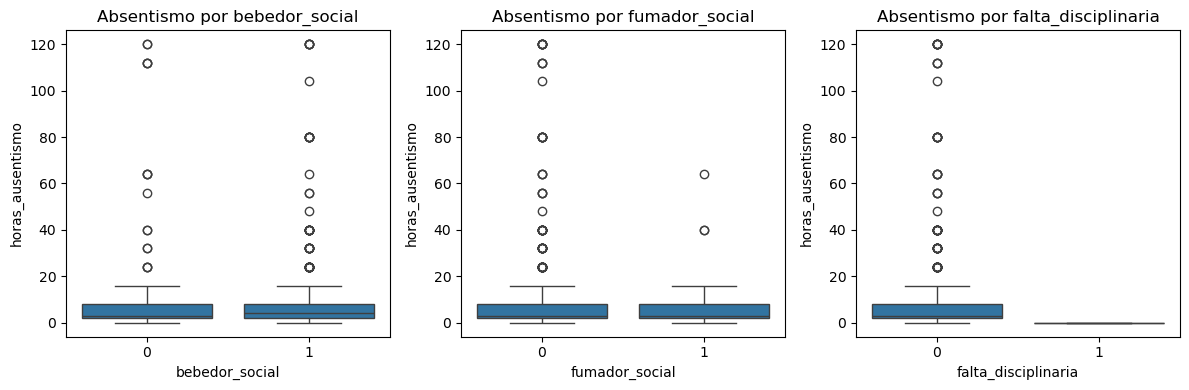

In [102]:
# 3. Análisis descriptivo
# ============================================================

# --- Estadísticos descriptivos por grupo ---
variables_estudio = ["bebedor_social", "fumador_social", "falta_disciplinaria"]

for var in variables_estudio:
    print(f"\n\n===== Distribución de horas de absentismo según {var} =====")
    print(df.groupby(var)["horas_ausentismo"].describe())

# --- Boxplots comparativos ---
plt.figure(figsize=(12,4))
for i, var in enumerate(variables_estudio, 1):
    plt.subplot(1,3,i)
    sns.boxplot(data=df, x=var, y="horas_ausentismo")
    plt.title(f"Absentismo por {var}")
plt.tight_layout()
plt.show()


## CREO NIVELES AUSENTISMO

In [103]:
df_clean.columns


Index(['id', 'motivo_ausencia', 'mes_ausencia', 'dia_semana', 'estaciones',
       'gasto_transporte', 'distancia_casa_trabajo', 'tiempo_servicio', 'edad',
       'carga_trabajo_diaria', 'cumplimiento_objetivo', 'falta_disciplinaria',
       'educacion', 'hijos', 'bebedor_social', 'fumador_social',
       'indice_masa_corporal', 'horas_ausentismo', 'indicador_enfermedad',
       'motivo_ausencia_mapeado', 'mes_ausencia_mapeado', 'educacion_mapeada'],
      dtype='object')

## Ramdom Forest

In [104]:
df_rf = df_clean[
    (df_clean['falta_disciplinaria'] == 0) & 
    (df_clean['horas_ausentismo'] > 0)
].copy()

df_rf['nivel_ausentismo'] = pd.cut(
    df_rf['horas_ausentismo'],
    bins=[0, 8, 24, 72, float('inf')],
    right=True,
    labels=['Bajo', 'Moderado', 'Alto', 'Critico']
)

print("NaN in nivel_ausentismo:", df_rf['nivel_ausentismo'].isna().sum())
print("\nDistribuzione livelli:")
print(df_rf['nivel_ausentismo'].value_counts())
print(f"\nTotale righe: {len(df_rf)}")

NaN in nivel_ausentismo: 0

Distribuzione livelli:
nivel_ausentismo
Bajo        900
Moderado     52
Alto         30
Critico      18
Name: count, dtype: int64

Totale righe: 1000


## Controlo si alguien tiene ausensia y faltas disciplinaria --> df_clean

In [105]:
# Empleados que tienen al menos una falta disciplinaria
empleados_con_falta = df_clean[df_clean['falta_disciplinaria'] == 1]['id'].unique()

# De esos empleados, ¿tienen también registros de ausencias normales (horas > 0)?
registros_mixtos = df_clean[
    (df_clean['id'].isin(empleados_con_falta)) & 
    (df_clean['horas_ausentismo'] > 0)
]

print(f"Empleados con al menos una falta disciplinaria: {len(empleados_con_falta)}")
print(f"De esos, registros con horas > 0: {len(registros_mixtos)}")
print(f"Empleados que tienen AMBAS cosas: {registros_mixtos['id'].nunique()}")

Empleados con al menos una falta disciplinaria: 31
De esos, registros con horas > 0: 449
Empleados que tienen AMBAS cosas: 20


## Controlo si alguien tiene ausencia y faltas disciplinaria --> df_rf

In [107]:
# Empleados que tienen al menos una falta disciplinaria
empleados_con_falta = df_rf[df_rf['falta_disciplinaria'] == 1]['id'].unique()

# De esos empleados, ¿tienen también registros de ausencias normales (horas > 0)?
registros_mixtos = df_rf[
    (df_rf['id'].isin(empleados_con_falta)) & 
    (df_rf['horas_ausentismo'] > 0)
]

print(f"Empleados con al menos una falta disciplinaria: {len(empleados_con_falta)}")
print(f"De esos, registros con horas > 0: {len(registros_mixtos)}")
print(f"Empleados que tienen AMBAS cosas: {registros_mixtos['id'].nunique()}")

Empleados con al menos una falta disciplinaria: 0
De esos, registros con horas > 0: 0
Empleados que tienen AMBAS cosas: 0


Train: 767 ausencias | Test: 233 ausencias
Empleados en train: 296 | en test: 75

--- Classification Report ---
              precision    recall  f1-score   support

        Bajo       0.94      0.76      0.84       217
    Moderado       0.25      0.09      0.13        11
        Alto       0.00      0.00      0.00         2
     Critico       0.02      0.33      0.04         3

    accuracy                           0.71       233
   macro avg       0.30      0.30      0.25       233
weighted avg       0.88      0.71      0.79       233



c:\Users\acaro\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\acaro\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\acaro\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


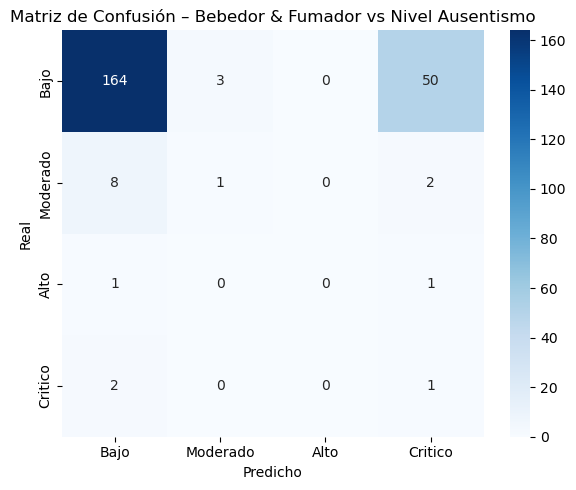

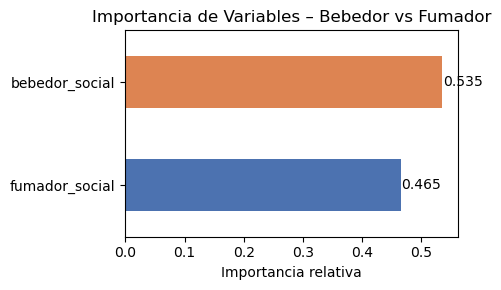

In [106]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------
# 1. VARIABLES
# -------------------------------------------------------
features = ['bebedor_social', 'fumador_social']
order = ['Bajo', 'Moderado', 'Alto', 'Critico']

X = df_rf[features].copy()
y = df_rf['nivel_ausentismo'].astype(str).map({v: i for i, v in enumerate(order)})
groups = df_rf['id']

# -------------------------------------------------------
# 2. SPLIT POR GRUPO
# -------------------------------------------------------
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train: {len(X_train)} ausencias | Test: {len(X_test)} ausencias")
print(f"Empleados en train: {groups.iloc[train_idx].nunique()} | en test: {groups.iloc[test_idx].nunique()}")

# -------------------------------------------------------
# 3. RANDOM FOREST
# -------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

# -------------------------------------------------------
# 4. EVALUACIÓN
# -------------------------------------------------------
y_pred = rf.predict(X_test)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=order))

# -------------------------------------------------------
# 5. MATRIZ DE CONFUSIÓN
# -------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=order, yticklabels=order, ax=ax)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión – Bebedor & Fumador vs Nivel Ausentismo')
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# 6. IMPORTANCIA DE VARIABLES
# -------------------------------------------------------
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(5, 3))
importances.plot(kind='barh', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('Importancia de Variables – Bebedor vs Fumador')
ax.set_xlabel('Importancia relativa')
for i, v in enumerate(importances):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

=== VERIFICACIÓN DATASET ===
Total registros: 1000
NaN en nivel_ausentismo: 0

Distribución nivel_ausentismo:
nivel_ausentismo
Bajo        900
Moderado     52
Alto         30
Critico      18
Name: count, dtype: int64

Distribución tiene_antecedente_disc:
tiene_antecedente_disc
0    551
1    449
Name: count, dtype: int64

=== MANN-WHITNEY U - IMPACTO SOBRE HORAS DE AUSENCIA ===

bebedor_social:
  Mediana grupo 0: 3.0h | Mediana grupo 1: 4.0h
  U=105948, p=0.0001 → ✅ SIGNIFICATIVO

fumador_social:
  Mediana grupo 0: 3.0h | Mediana grupo 1: 8.0h
  U=26875, p=0.2243 → ❌ No significativo

tiene_antecedente_disc:
  Mediana grupo 0: 3.0h | Mediana grupo 1: 4.0h
  U=120256, p=0.4388 → ❌ No significativo


C:\Users\acaro\AppData\Local\Temp\ipykernel_17152\2161926918.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_plot, labels=['No (0)', 'Sí (1)'])
C:\Users\acaro\AppData\Local\Temp\ipykernel_17152\2161926918.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_plot, labels=['No (0)', 'Sí (1)'])
C:\Users\acaro\AppData\Local\Temp\ipykernel_17152\2161926918.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_plot, labels=['No (0)', 'Sí (1)'])


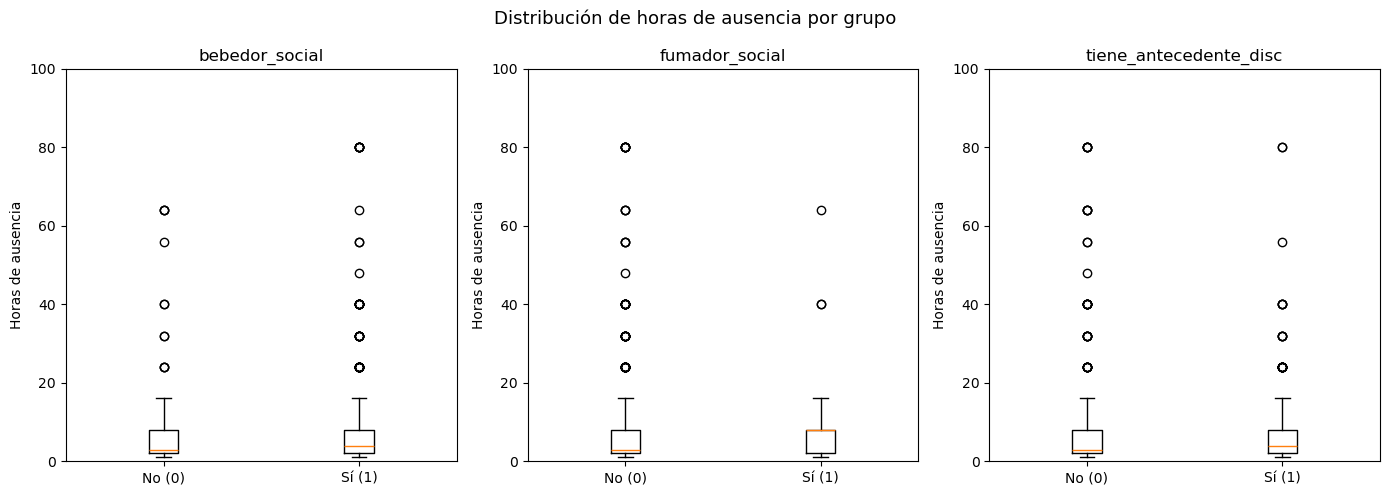


=== RANDOM FOREST ===
Train: 767 ausencias | Test: 233 ausencias
Empleados en train: 296 | en test: 75

--- Classification Report ---
              precision    recall  f1-score   support

        Bajo       0.93      0.77      0.84       217
    Moderado       0.08      0.09      0.08        11
        Alto       0.00      0.00      0.00         2
     Critico       0.02      0.33      0.05         3

    accuracy                           0.73       233
   macro avg       0.26      0.30      0.24       233
weighted avg       0.87      0.73      0.79       233



c:\Users\acaro\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\acaro\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\acaro\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


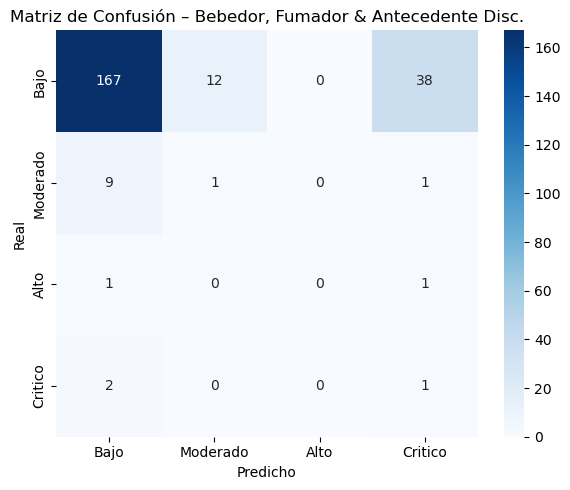

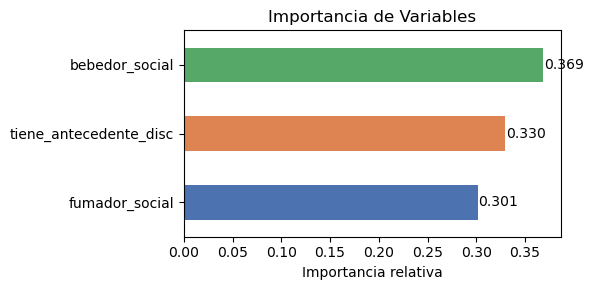

In [108]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------
# 1. PREPARACIÓN DEL DATASET
# -------------------------------------------------------
# Solo ausencias normales (excluye faltas disciplinarias y horas = 0)
df_rf = df_clean[
    (df_clean['falta_disciplinaria'] == 0) &
    (df_clean['horas_ausentismo'] > 0)
].copy()

# Variable a nivel de empleado: ¿tuvo alguna vez una falta disciplinaria?
empleados_con_falta = df_clean[df_clean['falta_disciplinaria'] == 1]['id'].unique()
df_rf['tiene_antecedente_disc'] = df_rf['id'].isin(empleados_con_falta).astype(int)

# Crear nivel de ausentismo
df_rf['nivel_ausentismo'] = pd.cut(
    df_rf['horas_ausentismo'],
    bins=[0, 8, 24, 72, float('inf')],
    right=True,
    labels=['Bajo', 'Moderado', 'Alto', 'Critico']
)

print("=== VERIFICACIÓN DATASET ===")
print(f"Total registros: {len(df_rf)}")
print(f"NaN en nivel_ausentismo: {df_rf['nivel_ausentismo'].isna().sum()}")
print(f"\nDistribución nivel_ausentismo:")
print(df_rf['nivel_ausentismo'].value_counts())
print(f"\nDistribución tiene_antecedente_disc:")
print(df_rf['tiene_antecedente_disc'].value_counts())

# -------------------------------------------------------
# 2. TEST DE MANN-WHITNEY U
# -------------------------------------------------------
print("\n=== MANN-WHITNEY U - IMPACTO SOBRE HORAS DE AUSENCIA ===")

variables = ['bebedor_social', 'fumador_social', 'tiene_antecedente_disc']

for var in variables:
    grupo_0 = df_rf[df_rf[var] == 0]['horas_ausentismo']
    grupo_1 = df_rf[df_rf[var] == 1]['horas_ausentismo']
    
    stat, p = stats.mannwhitneyu(grupo_0, grupo_1, alternative='two-sided')
    
    mediana_0 = grupo_0.median()
    mediana_1 = grupo_1.median()
    
    significativo = "✅ SIGNIFICATIVO" if p < 0.05 else "❌ No significativo"
    
    print(f"\n{var}:")
    print(f"  Mediana grupo 0: {mediana_0:.1f}h | Mediana grupo 1: {mediana_1:.1f}h")
    print(f"  U={stat:.0f}, p={p:.4f} → {significativo}")

# -------------------------------------------------------
# 3. VISUALIZACIÓN MANN-WHITNEY
# -------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, var in enumerate(variables):
    data_plot = [
        df_rf[df_rf[var] == 0]['horas_ausentismo'],
        df_rf[df_rf[var] == 1]['horas_ausentismo']
    ]
    axes[i].boxplot(data_plot, labels=['No (0)', 'Sí (1)'])
    axes[i].set_title(var)
    axes[i].set_ylabel('Horas de ausencia')
    axes[i].set_ylim(0, 100)  # limita el eje para mejor visualización

plt.suptitle('Distribución de horas de ausencia por grupo', fontsize=13)
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# 4. RANDOM FOREST
# -------------------------------------------------------
features = ['bebedor_social', 'fumador_social', 'tiene_antecedente_disc']
order = ['Bajo', 'Moderado', 'Alto', 'Critico']

X = df_rf[features].copy()
y = df_rf['nivel_ausentismo'].astype(str).map({v: i for i, v in enumerate(order)})
groups = df_rf['id']

# Split por grupo
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"\n=== RANDOM FOREST ===")
print(f"Train: {len(X_train)} ausencias | Test: {len(X_test)} ausencias")
print(f"Empleados en train: {groups.iloc[train_idx].nunique()} | en test: {groups.iloc[test_idx].nunique()}")

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=order))

# -------------------------------------------------------
# 5. MATRIZ DE CONFUSIÓN
# -------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=order, yticklabels=order, ax=ax)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión – Bebedor, Fumador & Antecedente Disc.')
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# 6. FEATURE IMPORTANCE
# -------------------------------------------------------
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(6, 3))
importances.plot(kind='barh', ax=ax, color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_title('Importancia de Variables')
ax.set_xlabel('Importancia relativa')
for i, v in enumerate(importances):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

In [110]:
len(empleados_con_falta)

31

In [112]:
print(df_rf['bebedor_social'].value_counts())
print(df_rf['tiene_antecedente_disc'].value_counts())

bebedor_social
1    549
0    451
Name: count, dtype: int64
tiene_antecedente_disc
0    551
1    449
Name: count, dtype: int64
